In [2]:
!pip install pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
covid = pd.read_csv("data/processed/covid_cases.csv")
vacc  = pd.read_csv("data/processed/covid_vaccinations.csv")
hosp  = pd.read_csv("data/processed/covid_hospital.csv")
mpox  = pd.read_csv("data/processed/mpox.csv")
pop   = pd.read_csv("data/processed/population.csv")

for df in [covid, vacc, hosp, mpox]:
    df['date'] = pd.to_datetime(df['date'])

covid = covid.merge(pop, on='country', how='left')
mpox  = mpox.merge(pop, on='country', how='left')

print("Loaded and merged")
print(f"  covid : {covid.shape}  | population col: {'population' in covid.columns}")
print(f"  vacc  : {vacc.shape}")
print(f"  hosp  : {hosp.shape}")
print(f"  mpox  : {mpox.shape}   | population col: {'population' in mpox.columns}")
print(f"  pop   : {pop.shape}")
print()



✅ Loaded and merged
  covid : (558258, 18)  | population col: True
  vacc  : (203057, 8)
  hosp  : (46777, 8)
  mpox  : (160599, 14)   | population col: True
  pop   : (265, 2)

🇰🇿 Kazakhstan population: 20,592,571


In [ ]:
def missing_report(df, name):
    print(f"\n {name.upper()} — пропуски:")
    missing = (df.isnull().sum() / len(df) * 100).round(1)
    for col, pct in missing.items():
        bar = "█" * int(pct / 5) + "░" * (20 - int(pct / 5))
        status = "✅" if pct == 0 else ("⚠️ " if pct < 30 else "❌")
        print(f"  {status} {col:<45} {pct:>5.1f}% |{bar}|")

missing_report(covid, "covid_cases")
missing_report(vacc, "covid_vaccinations")
missing_report(hosp, "covid_hospital")
missing_report(mpox, "mpox")


 COVID_CASES — пропуски:
  ✅ country                                         0.0% |░░░░░░░░░░░░░░░░░░░░|
  ✅ date                                            0.0% |░░░░░░░░░░░░░░░░░░░░|
  ⚠️  new_cases                                       0.7% |░░░░░░░░░░░░░░░░░░░░|
  ✅ total_cases                                     0.0% |░░░░░░░░░░░░░░░░░░░░|
  ⚠️  new_deaths                                      0.5% |░░░░░░░░░░░░░░░░░░░░|
  ✅ total_deaths                                    0.0% |░░░░░░░░░░░░░░░░░░░░|
  ⚠️  new_cases_7_day_avg_right                       0.9% |░░░░░░░░░░░░░░░░░░░░|
  ⚠️  new_deaths_7_day_avg_right                      0.7% |░░░░░░░░░░░░░░░░░░░░|
  ⚠️  new_cases_per_million                           0.7% |░░░░░░░░░░░░░░░░░░░░|
  ⚠️  new_deaths_per_million                          0.5% |░░░░░░░░░░░░░░░░░░░░|
  ✅ total_cases_per_million                         0.0% |░░░░░░░░░░░░░░░░░░░░|
  ✅ total_deaths_per_million                        0.0% |░░░░░░░░░░░░░░░░░░░░|
  

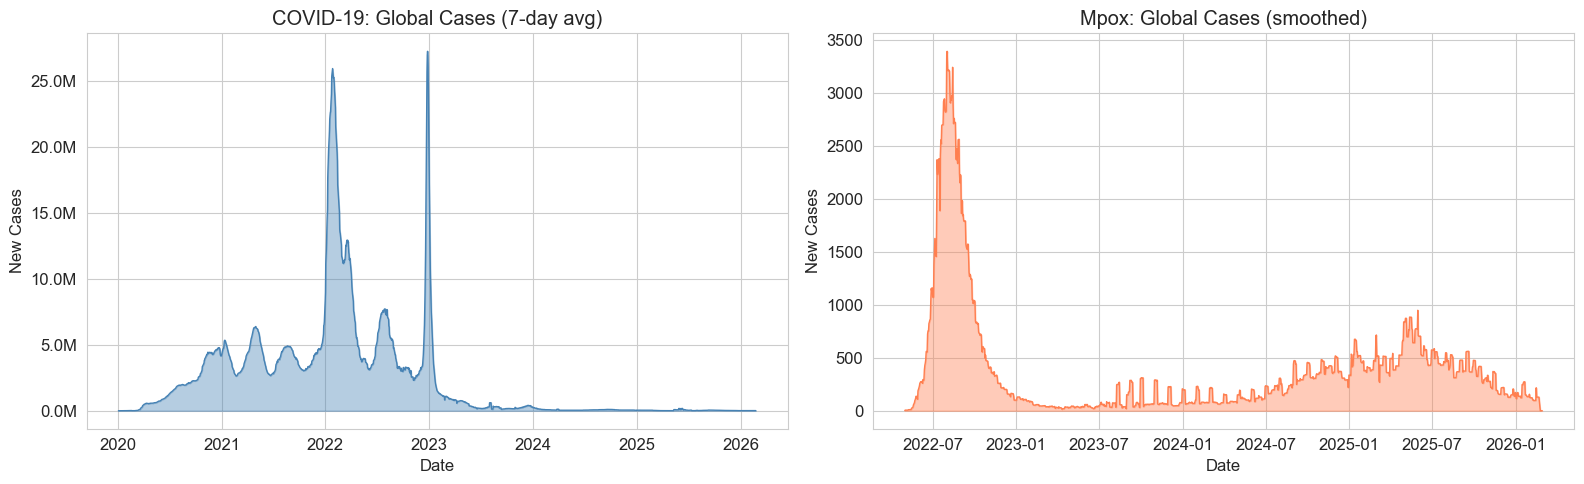

 Saved: data/processed/plot_global_trends.png


In [8]:
covid_global = covid.groupby('date')['new_cases_7_day_avg_right'].sum().reset_index()
mpox_global  = mpox.groupby('date')['new_cases_smoothed'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].fill_between(covid_global['date'], covid_global['new_cases_7_day_avg_right'],
                     alpha=0.4, color='steelblue')
axes[0].plot(covid_global['date'], covid_global['new_cases_7_day_avg_right'],
             color='steelblue', linewidth=1)
axes[0].set_title('COVID-19: Global Cases (7-day avg)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('New Cases')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[1].fill_between(mpox_global['date'], mpox_global['new_cases_smoothed'],
                     alpha=0.4, color='coral')
axes[1].plot(mpox_global['date'], mpox_global['new_cases_smoothed'],
             color='coral', linewidth=1)
axes[1].set_title('Mpox: Global Cases (smoothed)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('New Cases')

plt.tight_layout()
plt.savefig("data/processed/plot_global_trends.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: data/processed/plot_global_trends.png")


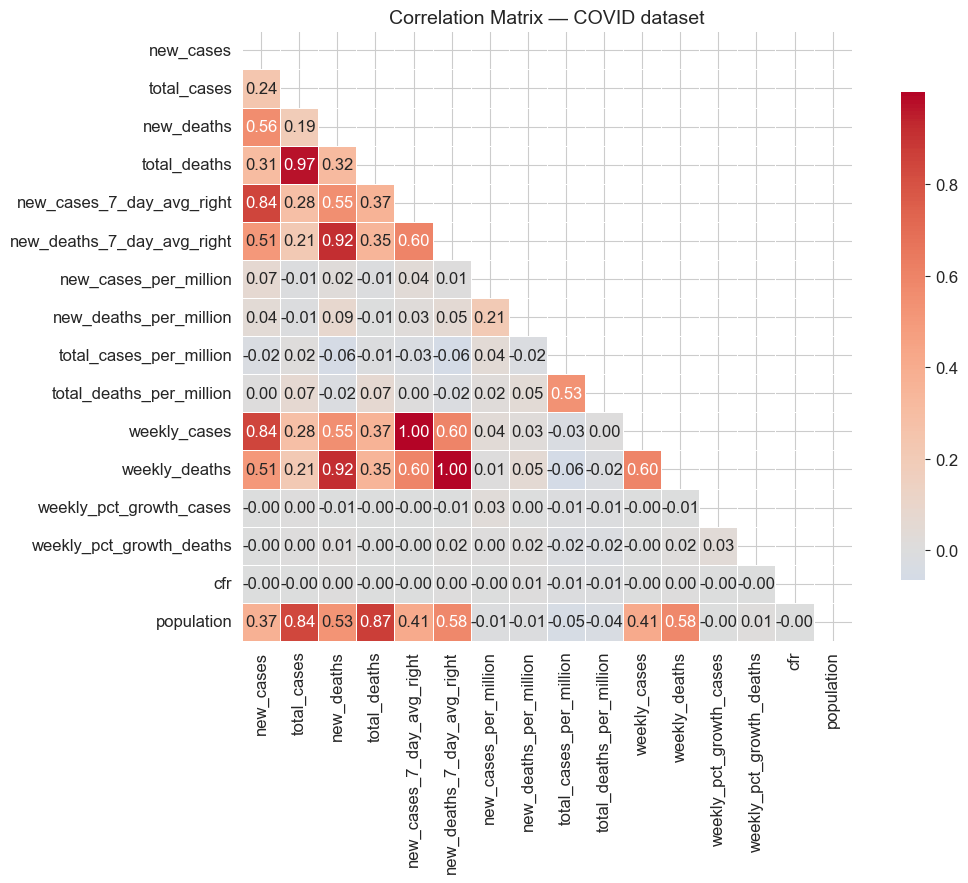

In [9]:
num_cols = covid.select_dtypes(include=[np.number]).columns.tolist()
corr = covid[num_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix — COVID dataset', fontsize=14)
plt.tight_layout()
plt.savefig("data/processed/plot_correlations.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
def add_features(df, disease_name):
    """Add time, normalization, lag and rolling features for ML"""
    df = df.copy()
    df = df.sort_values(['country', 'date'])

    df['year']        = df['date'].dt.year
    df['month']       = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['quarter']     = df['date'].dt.quarter
    df['season']      = df['month'].map({
        12: 'winter', 1: 'winter', 2: 'winter',
        3:  'spring', 4: 'spring', 5: 'spring',
        6:  'summer', 7: 'summer', 8: 'summer',
        9:  'autumn', 10:'autumn', 11:'autumn'
    })

    
    if 'population' in df.columns:
        df['new_cases_per_100k']  = df['new_cases']  / (df['population'] / 100_000)
        df['new_deaths_per_100k'] = df['new_deaths'] / (df['population'] / 100_000)
    else:
        df['new_cases_per_100k']  = df.get('new_cases_per_million',  0) / 10
        df['new_deaths_per_100k'] = df.get('new_deaths_per_million', 0) / 10

    smooth_col = 'new_cases_7_day_avg_right' if 'new_cases_7_day_avg_right' in df.columns                  else 'new_cases_smoothed'

    for lag in [7, 14, 21]:
        df[f'cases_lag_{lag}d'] = df.groupby('country')[smooth_col].shift(lag)

    df['cases_ma_30d'] = df.groupby('country')[smooth_col].transform(
        lambda x: x.rolling(30, min_periods=1).mean()
    )

    df['disease'] = disease_name

    return df


covid_feat = add_features(covid, 'covid')
mpox_feat  = add_features(mpox,  'mpox')

print(f"\nCOVID : {covid.shape[1]} columns → {covid_feat.shape[1]} columns")
print(f"Mpox  : {mpox.shape[1]} columns → {mpox_feat.shape[1]} columns")
print(f"\nNew features: {[c for c in covid_feat.columns if c not in covid.columns]}")

kz = covid_feat[covid_feat['country'] == 'Kazakhstan']
if len(kz) > 0:
    peak = kz.loc[kz['new_cases_per_100k'].idxmax()]
    print(f"\n🇰🇿 KZ peak: {peak['date'].date()} — {peak['new_cases_per_100k']:.2f} cases per 100k/day")


✅ Features added

COVID : 18 columns → 30 columns
Mpox  : 14 columns → 26 columns

New features: ['year', 'month', 'day_of_week', 'quarter', 'season', 'new_cases_per_100k', 'new_deaths_per_100k', 'cases_lag_7d', 'cases_lag_14d', 'cases_lag_21d', 'cases_ma_30d', 'disease']

🇰🇿 KZ peak: 2022-01-21 — 79.84 cases per 100k/day


In [ ]:
combined = pd.concat([covid_feat, mpox_feat], ignore_index=True)
combined = combined.sort_values(['disease', 'country', 'date']).reset_index(drop=True)

print(f"Combined dataset: {combined.shape[0]:,} rows × {combined.shape[1]} columns")
print(f"\nDisease counts:")
print(combined['disease'].value_counts().to_string())
print(f"\nCountries: {combined['country'].nunique()}")
print(f"\nMissing values in key columns:")

key_cols = ['new_cases', 'new_deaths', 'new_cases_per_100k',
            'new_deaths_per_100k', 'cases_lag_7d', 'cases_ma_30d']
for col in key_cols:
    if col in combined.columns:
        pct = combined[col].isnull().mean() * 100
        status = "✅" if pct == 0 else ("⚠️ " if pct < 10 else "❌")
        print(f"  {status} {col:<35} {pct:.1f}%")


📊 Combined dataset: 718,857 rows × 33 columns

Disease counts:
disease
covid    558258
mpox     160599

Countries: 250

Missing values in key columns:
  ⚠️  new_cases                           0.5%
  ⚠️  new_deaths                          0.4%
  ❌ new_cases_per_100k                  23.6%
  ❌ new_deaths_per_100k                 23.5%
  ⚠️  cases_lag_7d                        1.1%
  ⚠️  cases_ma_30d                        0.7%


In [ ]:
os.makedirs("data/features", exist_ok=True)

combined.to_csv("data/features/combined_features.csv", index=False)

kz = combined[combined['country'] == 'Kazakhstan']
kz.to_csv("data/features/kazakhstan_features.csv", index=False)

size_mb = os.path.getsize("data/features/combined_features.csv") / (1024*1024)

